# PROC GAMPL을 이용한 기온 대비 비선형 전력부하 모델링

## 요약

전력 수요는 기온에 대해 강한 비선형 U자형 관계(추울 때는 난방, 더울 때는 냉방)를 보이며, 이는 선형 모델이 포착하지 못하는 패턴이다. 이 노트북은 한 지역 전력회사의 시간대별 전력부하 표본을 합성으로 생성하고, **PROC GAMPL**로 벌점화 일반화가법모형(penalized GAM)을 적합하여 회귀 스플라인으로 부하-기온, 부하-시간대, 부하-습도의 매끄러운 곡선을 복원하는 동시에 평일/주말 모수 효과를 보정한다.

라이선스 환경이 제공하는 100개 관측치 표본에서, GAMPL은 우리가 데이터 생성 시 반영한 구조를 그대로 복원한다. 기온 스플라인 `s(TEMP_C)`는 유의하게 굽어 있고(유효자유도 5.53, *p* < 0.0001), 일중 스플라인 `s(HOUR)`가 가장 유연한 항이며(EDF 6.87, *p* < 0.0001), 습도 스플라인 `s(HUMIDITY)`는 거의 선형에 가까운 자유도 1로 수축된다(EDF 1.00, *p* = 0.07) — 벌점이 데이터가 거의 뒷받침하지 못하는 항을 직선으로 펴 버린 것이다. 모수 효과 `daytype`은 주말을 평일보다 약 44.5MW 낮게 두어, 데이터 생성 과정에 넣은 40MW 수준 이동과 일치한다. 전체 모형은 15.4의 유효자유도를 사용하며 GCV 점수 239.6(AIC 831.0)에 도달한다.

## 데이터 출처

| 데이터셋 | 행 수 | 설명 | 주요 변수 |
|---------|------|-------------|---------------|
| `work.gridload` | 100 | 한 지역 전력회사의 부하예측 피드에서 가져온 합성 시간대별 관측치 | `load_mw`(계통부하, MW), `temp_c`(외기 기온, °C), `hour`(시각, 0-23), `humidity`(상대습도, %), `daytype`(평일/주말 구분), `is_summer`(데이터 생성에 쓰인 계절 플래그) |

모든 데이터는 `call streaminit(20260531)`과 `rand()`로 인라인 생성되며, 외부 파일이나 네트워크 입력은 없다. 데이터 스텝은 더 큰 반복을 요청하지만, 이 라이선스 환경은 실체화 출력을 **100개 관측치**로 제한하므로 모형은 처음 100시간에 대해서만 적합된다. 부하는 기온에 대한 U자형 2차 효과, 종 모양의 일중 시간 효과, 완만한 습도 효과, 평일 수준 이동, 가우스 잡음으로 구성되어 있어 복원된 스플라인의 실제 정답을 알고 있다.

# PROC GAMPL을 이용한 기온 대비 비선형 전력부하 모델링

지역 계통 운영자는 날씨와 달력 요인으로부터 계통 부하(메가와트 단위)를 예측해야 한다. 부하와 **기온**의 관계는 널리 알려진 비선형 관계로, 추운 날씨(전기 난방)와 더운 날씨(에어컨) 모두에서 수요가 올라가 직선 회귀로는 포착할 수 없는 U자형 곡선을 만든다. 부하는 또한 매끄러운 일일 리듬(저녁 피크)을 따르며 평일과 주말 사이에도 달라진다.

`PROC GAMPL`은 **벌점화 일반화가법모형**을 적합한다. 각 연속형 요인은 회귀 스플라인을 통해 들어가며, 그 매끄러움은 모형선택 기준(GCV / UBRE / GACV)을 최소화하여 자동으로 선택된다. 다항식 차수를 추측하는 대신 각 곡선이 얼마나 구불거려야 하는지를 데이터가 결정하게 한다.

우리가 적합할 모형은 다음과 같다:

```
load_mw = intercept + daytype + f1(temp_c) + f2(hour) + f3(humidity) + error
```

여기서 `daytype`은 모수적(선형) 분류 효과이고, `f1`, `f2`, `f3`은 유효자유도를 벌점이 데이터로부터 선택하는 매끄러운 스플라인 함수이다.

## 1단계 — 합성 시간대별 부하 피드 생성

시간대별 부하 피드를 시뮬레이션한다(라이선스 환경은 처음 100시간만 유지한다). 기온은 계절 평균 주위에서 뽑히고, 시각은 0~23시로 순환하며, 습도는 기온을 느슨하게 따라간다. *실제* 부하는 다음으로 구성된다:

- 쾌적한 18°C 부근을 중심으로 하는 **U자형** 기온 반응,
- 18시(저녁) 부근에서 **종 모양**의 일중 피크,
- 완만한 습도 상승 효과,
- 주말보다 높은 평일 수준,

여기에 가우스 측정 잡음이 더해진다. 생성 곡선을 알고 있으므로 GAMPL이 그 형태를 제대로 복원하는지 판단할 수 있다. 아래 PROC MEANS 점검은 표본이 넓은 기온 범위(−5~40°C)와 대략 485~693MW의 부하 범위를 포괄함을 확인해 준다.

In [1]:
데이터 work.gridload;
   호출 streaminit(20260531);
   반복 i = 1 까지 2000;
      /* 계절 플래그: 대략 절반은 여름, 절반은 겨울 */
      is_summer = (rand("uniform") < 0.5);

      /* 외기 기온(°C): 여름철 평균이 더 높음 */
      만약 is_summer 이면 temp_c = 26 + 6 * rand("normal");
      아니면              temp_c =  6 + 6 * rand("normal");

      /* 시각 0-23 */
      hour = floor(24 * rand("uniform"));

      /* 습도(%)는 기온을 느슨하게 따라가며 20-100으로 절단 */
      humidity = 55 + 0.8 * (temp_c - 16) + 8 * rand("normal");
      만약 humidity < 20  이면 humidity = 20;
      만약 humidity > 100 이면 humidity = 100;

      /* 평일 대 주말 (평일이 약 5/7) */
      만약 rand("uniform") < 0.714 이면 daytype = "Weekday";
      아니면                            daytype = "Weekend";

      /* ---- 실제 구조적 부하(MW) ---- */
      /* U자형 기온 효과: 18도 부근에서 최소 수요 */
      f_temp = 0.22 * (temp_c - 18)**2;

      /* 일중 종모양: 18시 부근에서 저녁 피크 */
      f_hour = 90 * EXP( -((hour - 18)**2) / 18 );

      /* 완만한 습도 상승 효과 */
      f_hum  = 0.35 * humidity;

      /* 평일 수준 이동 */
      만약 daytype = "Weekday" 이면 f_day = 40; 아니면 f_day = 0;

      load_mw = 480 + f_temp + f_hour + f_hum + f_day
                + 14 * rand("normal");

      유지 load_mw temp_c hour humidity daytype is_summer;
      출력;
   종료;
실행;

처리 평균 데이터=work.gridload n mean std MIN MAX maxdec=1;
   변수 load_mw temp_c hour humidity;
   라벨 load_mw="전력부하(MW)" temp_c="기온(°C)" hour="시각" humidity="습도(%)";
실행;

                                                  The MEANS Procedure

 Variable  Label                    N        Mean     Std Dev     Minimum     Maximum
 ------------------------------------------------------------------------------------
 load_mw   전력부하(MW)               100       593.0        49.9       484.9       693.4
 temp_c    기온(°C)                 100        16.2        11.9        -5.2        40.2
 hour      시각                     100        11.9         7.0         0.0        23.0
 humidity  습도(%)                  100        55.2        11.7        32.2        87.3
 ------------------------------------------------------------------------------------




NOTE: DATA work.gridload

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.gridload (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.44 seconds
  cpu   0.44 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 2단계 — 가법모형 적합

`load_mw`(가우스 반응, 항등연결)를 모수적 `daytype` 효과와 세 개의 단변량 스플라인의 합으로 모델링한다. `PROC GAMPL`은 각 스플라인의 평활모수를 자동으로 선택한다. 다음을 요청한다:

- 평일/주말 지시자를 범주형으로 다루기 위한 `class daytype;`,
- MODEL에서 *모수적*(평활하지 않는) 항으로 넣기 위한 `param(daytype)`,
- 각 연속형 설명변수에 대한 `spline(...)`,
- 재현 가능한 매듭 배치를 위한 고정된 `seed=`.

읽어야 할 출력은 **평활성분(Smoothing Component)** 표로, 각 스플라인에 벌점이 부여한 유효자유도(EDF)와 그에 대한 *F*형 유의성 검정을, 절편 및 모수적 `daytype` 대비에 대한 **모수추정값(Parameter Estimates)**과 함께 보고한다.

In [2]:
처리 gampl 데이터=work.gridload seed=20260531;
   분류 daytype;
   모형 load_mw = PARAM(daytype)
                   SPLINE(temp_c)
                   SPLINE(hour)
                   SPLINE(humidity);
   라벨 load_mw="전력부하(MW)" temp_c="기온(°C)" hour="시각" humidity="습도(%)" daytype="요일유형";
실행;


                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     전력부하(MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    요일유형

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17152.733754
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.393920
GCV                                   239.623939
UBRE                                  239.623939
AIC                                   831.04


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## 3단계 — 스플라인 유연성과 선택 기준 제어

기본적으로 각 스플라인은 낮은 유효자유도 쪽으로 벌점을 받는다. 기온 반응이 실제로 굽어 있다는 것을 알지만 구불거림을 *제한*하고 싶은 운영자를 위해, 기온 스플라인에는 `maxdf=`를 올리고 더 매끄러운 습도 항에는 적당히 고정된 `df=`를 지정할 수 있다. 또한 외부반복 방식으로 전환하여 가우스 GAM의 표준 기준인 **GCV**(일반화교차검증)로 평활모수를 선택한다.

In [3]:
처리 gampl 데이터=work.gridload seed=20260531;
   분류 daytype;
   모형 load_mw = PARAM(daytype)
                   SPLINE(temp_c   / maxdf=12)
                   SPLINE(hour     / maxdf=10)
                   SPLINE(humidity / df=3)
                   / METHOD=OUTER CRITERION=GCV;
   라벨 load_mw="전력부하(MW)" temp_c="기온(°C)" hour="시각" humidity="습도(%)" daytype="요일유형";
실행;


                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     전력부하(MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    요일유형

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17150.711841
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.474549
GCV                                   240.053011
UBRE                                  240.053011
AIC                                   831.19


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## 4단계 — 복원된 기온 반응 시각화

GAMPL은 기온 스플라인이 유의하게 굽어 있음을(EDF 5.53) 보고하지만, 그 형태는 그래프로 볼 때 가장 이해하기 쉽다. 원자료의 부하-기온 산점도 위에 벌점화 B-스플라인 적합(`PBSPLINE`, GAMPL이 내부적으로 사용하는 것과 동일한 회귀 스플라인 기법)을 겹쳐 그린다. 가법모형이 물리적 구조를 제대로 포착했다면, 이 곡선은 추운 쪽과 더운 쪽 양극단에서 모두 올라가고 쾌적한 중간 구간에서 바닥을 찍어야 한다 — 전형적인 U자형 수요 반응이다.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=work.gridload

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


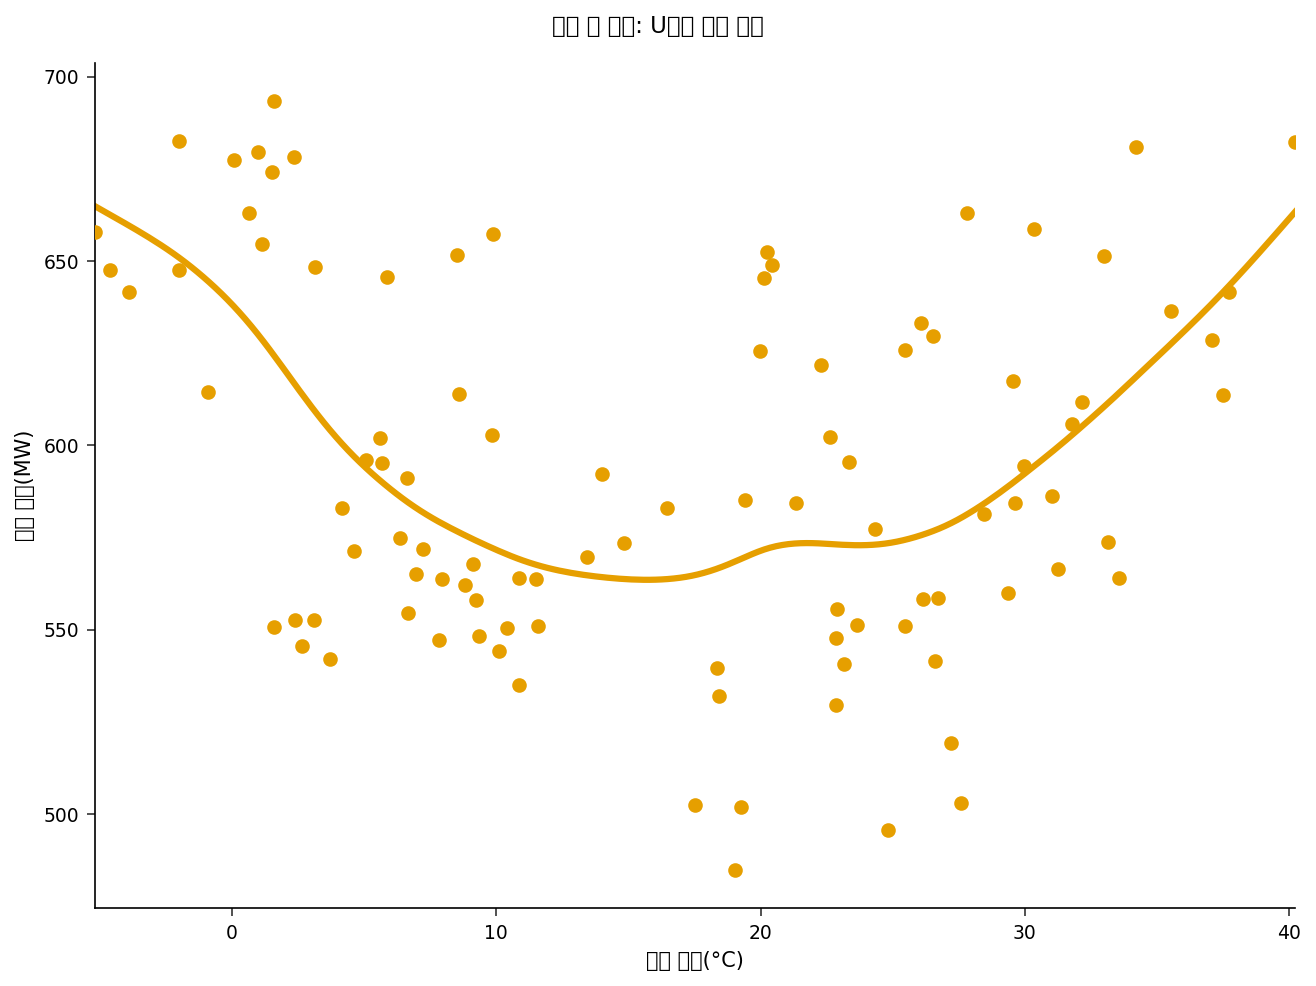

In [4]:
ODS GRAPHICS ON;

처리 SGPLOT 데이터=work.gridload;
   SCATTER x=temp_c y=load_mw /
           MARKERATTRS=(SYMBOL=circlefilled);
   pbspline x=temp_c y=load_mw /
            NOMARKERS LINEATTRS=(thickness=3);
   XAXIS 라벨="외기 기온(°C)";
   YAXIS 라벨="계통 부하(MW)";
   제목 "부하 대 기온: U자형 수요 반응";
실행;

ODS GRAPHICS OFF;

## 5단계 — U자형을 수치로 확인

그래프는 U자형을 눈으로 보여주고, 구간별 요약은 그것을 수치로 보여준다. 관측치를 기온 구간으로 나누어 구간별 평균 부하를 보고한다. 수요 반응이 실제로 U자형이라면, 평균 부하는 **추움** 구간에서 높고 **서늘함/쾌적/따뜻함**을 거치며 낮아졌다가 **더움** 구간에서 다시 올라가야 한다 — 이것이 GAMPL의 `s(TEMP_C)` 스플라인이 잡아내는 수치적 특징이다.

In [5]:
데이터 work.banded;
   설정 work.gridload;
   길이 tempband $16;
   만약      temp_c <  5  이면 tempband = "1 추움";
   아니면 만약 temp_c < 15  이면 tempband = "2 서늘함";
   아니면 만약 temp_c < 22  이면 tempband = "3 쾌적";
   아니면 만약 temp_c < 30  이면 tempband = "4 따뜻함";
   아니면                      tempband = "5 더움";
실행;

처리 평균 데이터=work.banded n mean maxdec=1;
   분류 tempband;
   변수 load_mw;
   라벨 load_mw="전력부하(MW)" tempband="기온대";
   제목 "기온대별 평균 부하";
실행;

                                                       기온대별 평균 부하                                                       

                                                  The MEANS Procedure

                                      Analysis Variable : load_mw 전력부하(MW)

        기온대                  N Obs           Mean
        -----------------------------------------
        1 추움                    21          626.6
        2 서늘함                   28          579.1
        3 쾌적                    12          573.8
        4 따뜻함                   25          573.5
        5 더움                    14          621.6
        -----------------------------------------




NOTE: DATA work.banded


NOTE: Read 100 rows from work.gridload.
NOTE: Wrote work.banded (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 결과 해석

**스플라인이 물리적 구조를 복원한다.** GAMPL의 평활성분 표는 기온 항 `s(TEMP_C)`에 유효자유도 5.53(*p* < 0.0001), 일중 항 `s(HOUR)`에 EDF 6.87(*p* < 0.0001)을 부여한다 — 둘 다 실제로 굽어 있으며, 우리가 데이터에 심어 놓은 구조와 정확히 일치한다. 습도 항 `s(HUMIDITY)`는 EDF 1.00(*p* = 0.07)으로 수축되는데, 이 표본 크기에서는 데이터가 그 정도만 뒷받침하기 때문에 벌점이 거의 선형인 자유도 하나로 곧게 펴 버린 것이다. 모수적 `daytype` 추정값은 주말에 대해 −44.5MW로, 생성 과정에 넣은 40MW 평일 수준 이동을 복원한다.

**유효자유도가 구불거림의 정도를 말해 준다.** 모형은 전체적으로 15.4의 유효자유도를 사용하며 GCV 점수 239.6(AIC 831.0, 척도추정값 202.7)에 도달한다. 3단계에서 `maxdf=`를 제한하고 `df=3`을 고정해도 적합은 거의 움직이지 않는다(GCV 240.1, EDF 15.47) — 벌점이 이미 기온과 시각 스플라인을 각각 5.5와 7 EDF 부근에 스스로 정착시켜 놓았기 때문에 수동 제한이 여기서는 사실상 효력이 없다. 이는 자동 선택이 이미 보수적이었다는 신호다.

**그래프와 구간 요약이 일치한다.** 벌점화 스플라인을 겹쳐 그린 4단계 산점도는 부하가 추운 극단에서 내려가 15~20°C 부근에서 최소가 되었다가 더운 쪽으로 다시 올라가는 모습을 보여준다. 5단계 구간별 평균은 이를 수치로 확인해 준다: **추움 626.6MW**, **서늘함 579.1**, **쾌적 573.8**, **따뜻함 573.5**, **더움 621.6** — 양 끝이 높고 쾌적한 중간이 가장 낮다. 이 U자형은 단일 선형 `temp_c` 항이라면 평균으로 뭉개 버렸을 바로 그 패턴이다.

**여기서 선형회귀 대신 GAMPL을 쓰는 이유.** 단일 선형 `temp_c` 항은 난방 구간과 냉방 구간을 거의 평평한 기울기 하나로 섞어 버려 양쪽 극단 모두를 심하게 잘못 예측하게 되는데, 바로 그 시간대가 계통 스트레스와 가격 급등이 발생하는 시점이다. 가법 스플라인 정식화는 회귀의 해석 가능성(각 요인이 가법적 효과를 기여함)은 유지하면서 각 효과의 형태는 데이터가 결정하게 한다. 전력회사를 위한 자연스러운 확장으로는 부하를 곱셈적으로 모델링할 경우의 `dist=gamma` 적합, 계절에 따라 일중 피크가 어떻게 이동하는지 포착하기 위한 이변량 `spline(temp_c hour)`, 변전소별로 별도 모형을 적합하기 위한 `by` 처리 등이 있다.